# Article Dataset download and pre-processing
### Master Thesis: Marco Monteverde

First, we can use the OpenAlex API in order to download the data for each article which author is in our INFO-01 table

In [2]:
import pandas as pd
import requests
import time
import matplotlib.pyplot as plt

In [3]:
# === CONFIG ===
OPENALEX_BASE_URL = "https://api.openalex.org"
HEADERS = {"User-Agent": "YourAppName (mailto:your@email.com)"}
RATE_LIMIT_DELAY = 0.1  # Delay between requests to avoid rate-limiting

In [5]:
# === STEP 1: Load author names ===
df_authors = pd.read_excel('./authors_data/INFO-01_authors_enriched.xlsx')  # Adjust as needed
print(df_authors.columns)

# Ensure you have columns 'Nome' and 'Cognome' in the authors' file
author_names = df_authors[['Nome', 'Cognome']].dropna().values.tolist()

Index(['Fascia', 'Cognome e Nome', 'Cognome e Nome normalized',
       'Uppercase Surname', 'Cognome', 'Nome', 'Genere', 'Ateneo', 'Facoltà',
       'GSD 2024', 'SSD 2024', 'SSD 2015', 'SC 2015', 'Struttura di afferenza',
       'Servizio prestato in altro ateneo', 'molteplicità', 'OpenAlex ID',
       'OpenAlex Name', 'ORCID', 'H-Index', 'I10-Index', 'Works Count',
       'Cited By Count', 'Institution (OpenAlex)'],
      dtype='object')


In [6]:
# === STEP 2: Function to search and disambiguate authors ===
def search_author(first_name, last_name):
    full_name = f"{first_name} {last_name}"
    url = f"{OPENALEX_BASE_URL}/authors?search={full_name}"
    response = requests.get(url, headers=HEADERS)
    time.sleep(RATE_LIMIT_DELAY)
    
    if response.status_code != 200:
        print(f"Error fetching author {full_name}")
        return None
    
    results = response.json().get('results', [])
    
    # Basic disambiguation: return list of matches (to be manually/heuristically filtered)
    return results

In [7]:
# === STEP 3: Fetch works for a specific OpenAlex author ID ===
def get_author_works(author_id):
    works = []
    cursor = '*'
    while cursor:
        url = f"{OPENALEX_BASE_URL}/works?filter=authorships.author.id:{author_id}&per-page=200&cursor={cursor}"
        response = requests.get(url, headers=HEADERS)
        time.sleep(RATE_LIMIT_DELAY)
        if response.status_code != 200:
            break
        data = response.json()
        works.extend(data.get('results', []))
        cursor = data.get('meta', {}).get('next_cursor', None)
    return works

In [8]:
# === STEP 4: Extract article data
def extract_article_data(work):
    citation_normalized_percentile_obj = work.get('citation_normalized_percentile') or {}
    open_access_obj = work.get('open_access') or {}
    primary_location_obj = work.get('primary_location') or {}
    source_obj = primary_location_obj.get('source') or {}
    
    # Extract authors
    authorships = work.get('authorships', [])
    author_names = []
    institutions = set()

    authors_count = 0
    for auth in authorships:
        author = auth.get('author', {})
        author_names.append(author.get('display_name', ""))
        authors_count += 1

        for inst in auth.get('institutions', []):
            if inst and 'display_name' in inst:
                institutions.add(inst['display_name'])
    
    # Extract citation by years (to hava a more in-depth vision of each article)
    counts_by_year = work.get('counts_by_year', [])
    year_citations = []
    
    for year in counts_by_year:
        year_citations.append((year.get('year'), year.get('cited_by_count')))
        
    # Extract topics hierarchy. The scheme is: TOPIC --> SUBFIELD --> FIELD --> DOMAIN
    topics_obj = work.get('topics', [])
    topics_long_form = []     # This is a complete form of Topics
    topics_short_form = []    # This is only the essentials from Topics
    
    for topic in topics_obj:
        topic_name = topic.get('display_name')
        topic_score = topic.get('score')
        subfield_obj = topic.get('subfield')
        subfield_name = subfield_obj.get('display_name')
        field_obj = topic.get('field')
        field_name = field_obj.get('display_name')
        domain_obj = topic.get('domain')
        domain_name = domain_obj.get('display_name')
        topics_long_form.append("Topic: " + str(topic_name) + " | Topic Score: " + str(topic_score) + " | Subfield: " + str(subfield_name) + " | Field: " + str(field_name) + " | Domain: " + str(domain_name))
        topics_short_form.append(topic_name)
        
    # Extract Keywords. The structure is similar to the topics one, so it's easy
    keywords_obj = work.get('keywords', [])
    keywords_long_form = []
    keywords_short_form = []
    
    for keyword in keywords_obj:
        keyword_name = keyword.get('display_name')
        keyword_score = keyword.get('score')
        keywords_long_form.append("Keyword: " + str(keyword_name) + " | Score: " + str(keyword_score))
        keywords_short_form.append(keyword_name)
        
    return {
        'Title': work.get('title'),
        'Authors': author_names,
        'Authors count': authors_count,
        'Institutions': "; ".join(sorted(institutions)),
        'Year': work.get('publication_year'),
        'Type': work.get('type'),
        'Venue': source_obj.get('display_name'),
        'Topics (Short form)': topics_short_form,
        'Topics (Long form)': topics_long_form,
        'Keywords (Short form)': keywords_short_form,
        'Keywords (Long form)': keywords_long_form,
        'Cites': work.get('referenced_works_count'),
        'Citations': work.get('cited_by_count'),
        'Citation normalized percentile': citation_normalized_percentile_obj.get('value'),
        'Citations by Year': year_citations,
        'Open Access status': open_access_obj.get('oa_status'),
        'Language': work.get('language'),
        'Abstract inverted index': work.get('abstract_inverted_index')
    }

In [9]:
# === STEP 5: Loop through authors and collect data ===
all_articles = []

entry_count = 0
for first, last in author_names:
    entry_count += 1
    print(f"Author {entry_count} - Searching for: {first} {last}")
    candidates = search_author(first, last)
    
    if not candidates:
        continue
    
    # For now, choose the top result; disambiguation can be added here
    author = candidates[0]  # You can refine this with more logic
    author_id = author['id']
    
    print(f"Fetching works for: {author['display_name']} ({author_id})")
    works = get_author_works(author_id)
    
    for work in works:
        article = extract_article_data(work)
        all_articles.append(article)

Author 1 - Searching for: Andrea Francesco Abate
Fetching works for: Andrea F. Abate (https://openalex.org/A5038161482)
Author 2 - Searching for: Fabio Abbattista
Fetching works for: Fabio Abbattista (https://openalex.org/A5055377934)
Author 3 - Searching for: Giovanni Acampora
Fetching works for: Giovanni Acampora (https://openalex.org/A5023375107)
Author 4 - Searching for: Vincenzo Acciaro
Fetching works for: Vincenzo Acciaro (https://openalex.org/A5076111709)
Author 5 - Searching for: Luca Aceto
Fetching works for: Luca Aceto (https://openalex.org/A5041913577)
Author 6 - Searching for: Carlo Adornetto
Fetching works for: Carlo Adornetto (https://openalex.org/A5045483261)
Author 7 - Searching for: Alessandra Agostini
Fetching works for: Alessandra Agostini (https://openalex.org/A5110004806)
Author 8 - Searching for: Stefano Aguzzoli
Fetching works for: Stefano Aguzzoli (https://openalex.org/A5101825075)
Author 9 - Searching for: Dragan Ahmetovic
Fetching works for: Dragan Ahmetovic (

Author 73 - Searching for: Paola Barra
Fetching works for: Paola Barra (https://openalex.org/A5057985784)
Author 74 - Searching for: Silvio Barra
Fetching works for: Silvio Barra (https://openalex.org/A5041900092)
Author 75 - Searching for: Luis Alberto Barron Cedeno
Fetching works for: Luis Alberto Barrón Cedeño (https://openalex.org/A5113683886)
Author 76 - Searching for: Massimo Bartoletti
Fetching works for: Massimo Bartoletti (https://openalex.org/A5050606239)
Author 77 - Searching for: Novella Bartolini
Fetching works for: Novella Bartolini (https://openalex.org/A5081384199)
Author 78 - Searching for: Giacomo Baruzzo
Fetching works for: Giacomo Baruzzo (https://openalex.org/A5010617664)
Author 79 - Searching for: Francesco Basciani
Fetching works for: Francesco Basciani (https://openalex.org/A5039406054)
Author 80 - Searching for: Valerio Basile
Fetching works for: Valerio Basile (https://openalex.org/A5071473719)
Author 81 - Searching for: Roberto Basili
Fetching works for: Robe

Author 146 - Searching for: Nunzio Alberto Borghese
Fetching works for: N. Alberto Borghese (https://openalex.org/A5001947622)
Author 147 - Searching for: Manuel Alejandro Borroto Santana
Author 148 - Searching for: Luca Bortolussi
Fetching works for: Luca Bortolussi (https://openalex.org/A5060744592)
Author 149 - Searching for: Cristina Bosco
Fetching works for: Cristina Bosco (https://openalex.org/A5029663653)
Author 150 - Searching for: Andrea Bosin
Fetching works for: Andrea Bosin (https://openalex.org/A5027929641)
Author 151 - Searching for: Marco Botta
Fetching works for: Marco Botta (https://openalex.org/A5011448484)
Author 152 - Searching for: Riccardo Botteri
Author 153 - Searching for: Paolo Gaspare Bottoni
Author 154 - Searching for: Simone Bottoni
Fetching works for: S. Bottoni (https://openalex.org/A5062872185)
Author 155 - Searching for: Alessio Bottrighi
Fetching works for: Alessio Bottrighi (https://openalex.org/A5012918421)
Author 156 - Searching for: Laura Bozzelli
Fe

Author 220 - Searching for: Antonio Carta
Fetching works for: Antonio Carta (https://openalex.org/A5102872066)
Author 221 - Searching for: Salvatore Mario Carta
Fetching works for: Salvatore Carta (https://openalex.org/A5069275031)
Author 222 - Searching for: Antonio Mario Caruso
Fetching works for: Antonio Caruso (https://openalex.org/A5052992454)
Author 223 - Searching for: Roberto Casadei
Fetching works for: Roberto Casadei (https://openalex.org/A5076032146)
Author 224 - Searching for: Alberto Casagrande
Fetching works for: Alberto Casagrande (https://openalex.org/A5052391923)
Author 225 - Searching for: Emiliano Casalicchio
Fetching works for: Emiliano Casalicchio (https://openalex.org/A5059091002)
Author 226 - Searching for: Fabio Casati
Fetching works for: Fabio Casati (https://openalex.org/A5086585292)
Author 227 - Searching for: Pasquale Cascarano
Fetching works for: Pasquale Cascarano (https://openalex.org/A5066591000)
Author 228 - Searching for: Marco Cascio
Fetching works fo

Author 292 - Searching for: Stefano Cirillo
Fetching works for: Stefano Cirillo (https://openalex.org/A5104332791)
Author 293 - Searching for: Giulia Cisotto
Fetching works for: Giulia Cisotto (https://openalex.org/A5034563842)
Author 294 - Searching for: Antonio Cisternino
Fetching works for: Antonio Cisternino (https://openalex.org/A5019439932)
Author 295 - Searching for: Davide Elio Ciucci
Author 296 - Searching for: Gabriele Civitarese
Fetching works for: Gabriele Civitarese (https://openalex.org/A5068914794)
Author 297 - Searching for: Fabio Clarizia
Fetching works for: Fabio Clarizia (https://openalex.org/A5066430179)
Author 298 - Searching for: Andrea Clementi
Fetching works for: Andrea Clementi (https://openalex.org/A5001082357)
Author 299 - Searching for: Luisanna Cocco
Fetching works for: Luisanna Cocco (https://openalex.org/A5087692087)
Author 300 - Searching for: Daniele Codetta Raiteri
Fetching works for: Daniele Codetta‐Raiteri (https://openalex.org/A5081835685)
Author 30

...

Author 939 - Searching for: Mirko Polato
Fetching works for: Mirko Polato (https://openalex.org/A5009738158)
Author 940 - Searching for: Giuseppe Polese
Fetching works for: Giuseppe Polese (https://openalex.org/A5041872893)
Author 941 - Searching for: Alberto Policriti
Fetching works for: Alberto Policriti (https://openalex.org/A5042115100)
Author 942 - Searching for: Marco Polignano
Fetching works for: Marco Polignano (https://openalex.org/A5014793020)
Author 943 - Searching for: Andrea Polini
Fetching works for: Andrea Polini (https://openalex.org/A5016180635)
Author 944 - Searching for: Laura Pollacci
Fetching works for: Laura Pollacci (https://openalex.org/A5033722315)
Author 945 - Searching for: Matteo Polsinelli
Fetching works for: Matteo Polsinelli (https://openalex.org/A5003946769)
Author 946 - Searching for: Lucia Pomello Chinaglia Pomello
Fetching works for: Lucia Pomello (https://openalex.org/A5039309155)
Author 947 - Searching for: Livio Pompianu
Fetching works for: Livio P

Author 1011 - Searching for: Marco Roccetti
Fetching works for: Marco Roccetti (https://openalex.org/A5025338247)
Author 1012 - Searching for: Davide Rocchesso
Fetching works for: Davide Rocchesso (https://openalex.org/A5079160098)
Author 1013 - Searching for: Emanuele Rodolà
Fetching works for: Emanuele Rodolà (https://openalex.org/A5087051832)
Author 1014 - Searching for: Marco Romano
Fetching works for: Marco Romano (https://openalex.org/A5045864473)
Author 1015 - Searching for: Simona Ester Rombo
Fetching works for: Simona E. Rombo (https://openalex.org/A5047319643)
Author 1016 - Searching for: Rocco Rongo
Fetching works for: Rocco Rongo (https://openalex.org/A5089245215)
Author 1017 - Searching for: Andrea Rosani
Fetching works for: Andrea Rosani (https://openalex.org/A5109036666)
Author 1018 - Searching for: Lorenzo Rosasco
Fetching works for: Lorenzo Rosasco (https://openalex.org/A5061220999)
Author 1019 - Searching for: Alon Rosen
Fetching works for: Alon Rosen (https://openale

Author 1082 - Searching for: Luca Sciullo
Fetching works for: Luca Sciullo (https://openalex.org/A5023503670)
Author 1083 - Searching for: Gian Luca Scoccia
Fetching works for: Gian Luca Scoccia (https://openalex.org/A5060820537)
Author 1084 - Searching for: Fabio Scotti
Fetching works for: Fabio Scotti (https://openalex.org/A5004969615)
Author 1085 - Searching for: Francesca Scozzari
Fetching works for: Francesca Scozzari (https://openalex.org/A5080102700)
Author 1086 - Searching for: Michele Scquizzato
Fetching works for: Michele Scquizzato (https://openalex.org/A5072734392)
Author 1087 - Searching for: Roberto Segala
Fetching works for: Roberto Segala (https://openalex.org/A5006624231)
Author 1088 - Searching for: Marino Segnan
Fetching works for: Marino Segnan (https://openalex.org/A5069558697)
Author 1089 - Searching for: Giovanni Semeraro
Fetching works for: Giovanni Semeraro (https://openalex.org/A5059814300)
Author 1090 - Searching for: Laura Semini
Fetching works for: Laura Se

Author 1153 - Searching for: Stefania Tomasiello
Fetching works for: Stefania Tomasiello (https://openalex.org/A5039950678)
Author 1154 - Searching for: Claudio Tomazzoli
Fetching works for: Claudio Tomazzoli (https://openalex.org/A5054093778)
Author 1155 - Searching for: Roberto Tonelli
Fetching works for: Roberto Tonelli (https://openalex.org/A5059849543)
Author 1156 - Searching for: Alessandro Torcinovich
Fetching works for: Alessandro Torcinovich (https://openalex.org/A5054839433)
Author 1157 - Searching for: Massimo Torquati
Fetching works for: Massimo Torquati (https://openalex.org/A5053667707)
Author 1158 - Searching for: Ilaria Torre
Fetching works for: Ilaria Torre (https://openalex.org/A5031872492)
Author 1159 - Searching for: Gianluca Torta
Fetching works for: Gianluca Torta (https://openalex.org/A5067843040)
Author 1160 - Searching for: Genoveffa Tortora
Fetching works for: Genoveffa Tortora (https://openalex.org/A5074856207)
Author 1161 - Searching for: Domenico Tortorella

Fetching works for: Riccardo Zese (https://openalex.org/A5013157998)
Author 1227 - Searching for: Matteo Zignani
Fetching works for: Matteo Zignani (https://openalex.org/A5035471624)
Author 1228 - Searching for: Stefano Pio Zingaro
Fetching works for: Stefano Pio Zingaro (https://openalex.org/A5088115591)
Author 1229 - Searching for: Floriano Luca Zini
Fetching works for: Floriano Zini (https://openalex.org/A5027712364)
Author 1230 - Searching for: Simone Zini
Fetching works for: Simone Zini (https://openalex.org/A5006567602)
Author 1231 - Searching for: Rosalba Zizza
Fetching works for: Rosalba Zizza (https://openalex.org/A5085208855)
Author 1232 - Searching for: Fabiana Zollo
Fetching works for: Fabiana Zollo (https://openalex.org/A5038940357)
Author 1233 - Searching for: Tommaso Zoppi
Fetching works for: Tommaso Zoppi (https://openalex.org/A5027443752)
Author 1234 - Searching for: Italo Francesco Luigi Zoppis
Author 1235 - Searching for: Elena Zucca
Fetching works for: E. Zucca (htt

In [10]:
# === STEP 6: Convert to DataFrame and Save ===
df_articles = pd.DataFrame(all_articles)
df_articles.to_excel('./articles_data/INFO-01_articles.xlsx', index=False)
print("Saved data to 'INFO-01_articles.xlsx'")

Saved data to 'INFO-01_articles.xlsx'


## Statistics from INFO-01_articles.xlsx

In [18]:
# Languages distribution of articles in the dataset
language_counts = df_articles['Language'].value_counts(dropna=False)
language_relative = df_articles['Language'].value_counts(normalize=True, dropna=False) * 100

language_stats = pd.DataFrame({
    'count': language_counts,
    'percentage': language_relative.round(2)
})
print(language_stats)

       count  percentage
en    157616       96.31
it      2529        1.55
None    1533        0.94
fr       670        0.41
es       275        0.17
ja       230        0.14
de       189        0.12
ca       126        0.08
pt        94        0.06
ro        81        0.05
da        74        0.05
nl        51        0.03
tl        42        0.03
af        28        0.02
id        25        0.02
fi        19        0.01
no        17        0.01
et        15        0.01
sl         6        0.00
ko         6        0.00
hu         6        0.00
ru         5        0.00
cy         4        0.00
sv         3        0.00
cs         3        0.00
hr         3        0.00
pl         3        0.00
lt         2        0.00
el         1        0.00
sk         1        0.00
vi         1        0.00
bn         1        0.00
sw         1        0.00
so         1        0.00


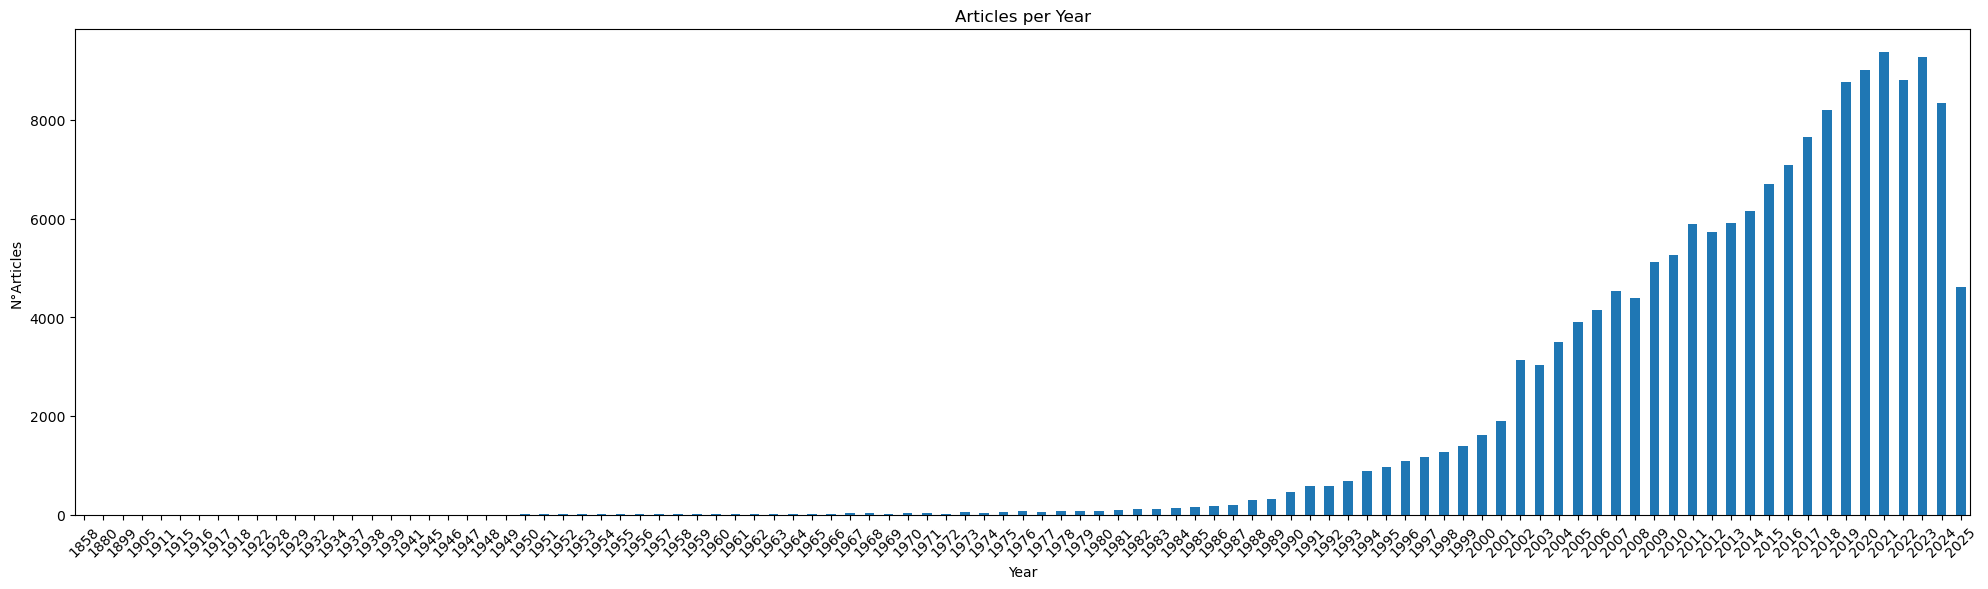

Oldest publication year: 1858
Most recent publication year: 2025
Median publication year: 2015.0
Average publications per year: 1653.14


In [19]:
# Articles per year
year_counts = df_articles['Year'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(20, 6))  # Wider figure
year_counts.plot(kind='bar', title='Articles per Year')
plt.xlabel("Year")
plt.ylabel("N°Articles")
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.tight_layout()       # Prevent cutoff

plt.show()

print("Oldest publication year:", df_articles['Year'].min())
print("Most recent publication year:", df_articles['Year'].max())
print("Median publication year:", df_articles['Year'].median())
print("Average publications per year:", round(year_counts.mean(), 2))

<Axes: title={'center': 'Avg Citation Percentile vs. N° Authors'}, xlabel='Authors count'>

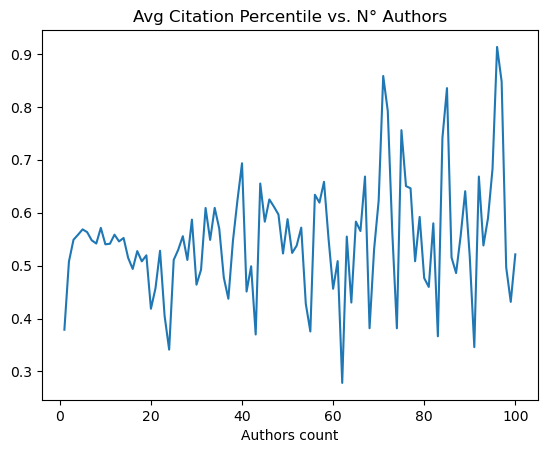

In [20]:
# Average Citation percentile vs Number of Authors
citation_by_authors = df_articles.groupby('Authors count')['Citation normalized percentile'].mean().dropna()
citation_by_authors.plot(kind='line', title='Avg Citation Percentile vs. N° Authors')

                          count  percentage
article                  108589       66.35
book-chapter              29338       17.93
preprint                  16139        9.86
book                       2538        1.55
dataset                    2333        1.43
review                     1922        1.17
paratext                    778        0.48
editorial                   492        0.30
letter                      445        0.27
dissertation                271        0.17
other                       225        0.14
erratum                     217        0.13
peer-review                 183        0.11
report                      120        0.07
supplementary-materials      52        0.03
reference-entry              15        0.01
retraction                    4        0.00


<Axes: title={'center': 'Publication Type Distribution'}>

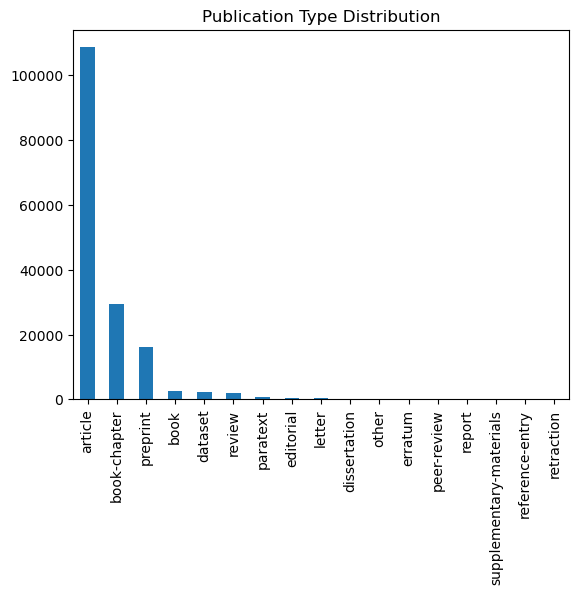

In [21]:
pub_type_counts = df_articles['Type'].value_counts(dropna=False)
pub_type_percent = df_articles['Type'].value_counts(normalize=True, dropna=False) * 100

pub_type_stats = pd.DataFrame({
    'count': pub_type_counts,
    'percentage': pub_type_percent.round(2)
})
print(pub_type_stats)

pub_type_counts.plot(kind='bar', title='Publication Type Distribution')

          count  percentage
closed   104879       64.08
green     26026       15.90
gold      11832        7.23
bronze    11384        6.96
hybrid     7566        4.62
diamond    1974        1.21


<Axes: title={'center': 'Open Access Status Distribution'}>

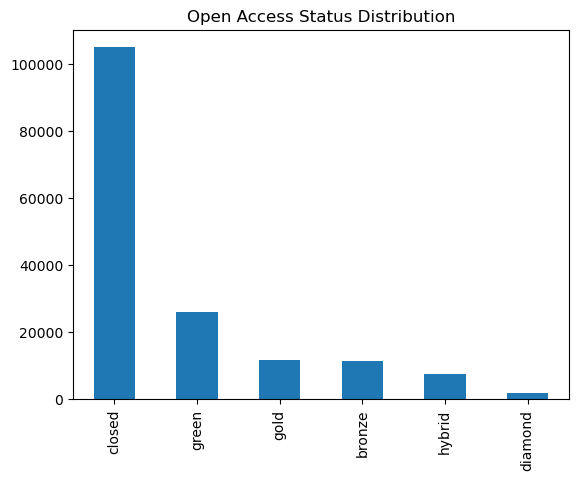

In [22]:
oa_counts = df_articles['Open Access status'].value_counts(dropna=False)
oa_percent = df_articles['Open Access status'].value_counts(normalize=True, dropna=False) * 100

oa_stats = pd.DataFrame({
    'count': oa_counts,
    'percentage': oa_percent.round(2)
})
print(oa_stats)

oa_counts.plot(kind='bar', title='Open Access Status Distribution')

In [23]:
# Flatten and explode the institutions list
df_exploded = df_articles.copy()
df_exploded['Institution list'] = df_exploded['Institutions'].str.split('; ')
top_institutions = df_exploded.explode('Institution list')['Institution list'].value_counts().head(10)
print(top_institutions)

                                38026
University of Milan             10124
University of Salerno            9907
University of Bologna            8726
University of Pisa               8583
University of Turin              8035
Sapienza University of Rome      7046
University of Milano-Bicocca     5144
University of Padua              4818
University of Bari Aldo Moro     4720
Name: Institution list, dtype: int64


In [24]:
most_cited = df_articles.sort_values(by='Citation normalized percentile', ascending=False).head(10)
print(most_cited[['Title', 'Authors', 'Citation normalized percentile', 'Year']])

                                                    Title  \
35976          Recursive patterns in online echo chambers   
103369  Privacy Perception when Using Smartphone Appli...   
71489   The limited reach of fake news on Twitter duri...   
144102  Understanding news outlets’ audience-targeting...   
71482                 The COVID-19 social media infodemic   
144117  VATAS: An Open-Source Web Platform for Visual ...   
53498   A blockchain based approach for the definition...   
162782  Dealing with digital misinformation: a polaris...   
36023   Measuring social response to different journal...   
53303   Understanding Customer Satisfaction With Servi...   

                                                  Authors  \
35976   [Emanuele Brugnoli, Matteo Cinelli, Walter Qua...   
103369  [Marco Furini, Silvia Mirri, Manuela Montanger...   
71489   [Matteo Cinelli, Stefano Cresci, Alessandro Ga...   
144102  [Erick Elejalde, Leo Ferres, Rossano Schifanella]   
71482   [Matteo Cinelli